In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df_0005   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/00.05.csv")
df_0305   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/03.05.csv")
df_0605   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/06.05.csv")
df_0905   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/09.05.csv")
df_1205   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/12.05.csv")
df_1505   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/15.05.csv")
df_1805   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/18.05.csv")
df_2105   = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/21.35.csv")

AfterPulse = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [3]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [5]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75

import numpy as np

bin_spacing_m = 3.75

def process_lidar_full_pipeline(df, afterpulse_df, config, bin_spacing_m=3.75, blend_extend_m=100):
    df = df.copy()

    # =========================
    # 0) Add bin index and range
    # =========================
    if "bin_index" in df.columns:
        df = df.drop(columns=["bin_index"])
    if "range_m" in df.columns:
        df = df.drop(columns=["range_m"])

    df.insert(0, "bin_index", np.arange(len(df)))
    df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

    # =========================
    # 1) Signal-to-noise ratio
    # =========================
    df["SNR_analog"] = df["analog"] / (df["analog_sterr"] + 1e-12)
    df["SNR_Photon"] = df["photon_counting"] / (df["pc_sterr"] + 1e-12)

    # =========================
    # 2) Convert MHz -> photon per bin
    # =========================
    df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

    # =========================
    # 3) Background region
    # =========================
    bg_row = df[
        (df["range_m"] >= config["bg_start_m"]) &
        (df["range_m"] <= config["bg_end_m"])
    ]

    Analog_bg_mean = bg_row["analog"].mean()
    Photon_bg_mean = bg_row["photon_per_bin"].mean()

    print("Analog background (mean):", Analog_bg_mean)
    print("Photon Per Bin background (mean):", Photon_bg_mean)

    # Background correction
    df["analog_bg_corr"] = df["analog"] - Analog_bg_mean
    df["Photon_per_bin_bg_corr"] = df["photon_per_bin"] - Photon_bg_mean

    # =========================
    # 4) Afterpulse correction
    # =========================
    # if len(afterpulse_df) != len(df):
    #     raise ValueError(
    #         f"Length mismatch: afterpulse_df has {len(afterpulse_df)} rows, "
    #         f"but df has {len(df)} rows"
    #     )

    # df["afterpulse_raw"] = afterpulse_df["afterpulse_raw"].to_numpy()
    # df["afterpulse_counts_per_bin"] = (
    #     df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
    # )

    # df["photon_APcorr_counts"] = (
    #     df["Photon_per_bin_bg_corr"] - df["afterpulse_counts_per_bin"]
    # )

    # =========================
    # 5) Dead-time correction
    # =========================
    bin_width_s = config["bin_width_ns"] * 1e-9
    dead_time_s = config["dead_time_ns"] * 1e-9

    # counts/bin -> rate (Hz)
    rate_meas_hz = df["Photon_per_bin_bg_corr"] / bin_width_s
    ratio = rate_meas_hz * dead_time_s

    # Non-paralyzable correction
    df["photon_deadtime_corr_hz"] = np.where(
        ratio < 1,
        rate_meas_hz / (1 - ratio),
        np.nan
    )

    # Hz -> counts/bin
    df["photon_deadtime_corr"] = df["photon_deadtime_corr_hz"] * bin_width_s

    # =========================
    # 6) Overlap region for gluing
    # =========================
    m_overlap = df[
        (df["range_m"] >= config["overlap_r1_m"]) &
        (df["range_m"] <= config["overlap_r2_m"])
    ].copy()

    # ใช้ photon ที่ corrected แล้วสำหรับ glue
    m_overlap = m_overlap.replace([np.inf, -np.inf], np.nan)
    m_overlap = m_overlap.dropna(subset=["analog_bg_corr", "Photon_per_bin_bg_corr"])

    x = m_overlap["analog_bg_corr"].to_numpy()
    y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

    if len(x) < 2:
        raise ValueError("Not enough valid points in overlap region for linregress.")

    k_scale, b_offset, r_lin, *_ = linregress(x, y)

    print("k_scale =", k_scale)
    print("b_offset =", b_offset)
    print("R^2 =", r_lin**2)

    # Scale analog to photon domain
    df["analog_scaled_for_glue"] = k_scale * df["analog_bg_corr"] + b_offset

    # =========================
    # 7) Smooth blending weights
    # =========================
    blend_r1_m = config["overlap_r1_m"] - blend_extend_m
    blend_r2_m = config["overlap_r2_m"] + blend_extend_m

    r = df["range_m"].to_numpy()
    w = np.zeros_like(r, dtype=float)

    # far range -> photon full weight
    w[r > blend_r2_m] = 1.0

    # blend region -> cosine
    m = (r >= blend_r1_m) & (r <= blend_r2_m)
    w[m] = 0.5 * (
        1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m))
    )

    df["weight_w"] = w

    # =========================
    # 8) Merge analog + photon
    # =========================
    df["merged_counts_per_bin"] = (
        (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
        + df["weight_w"] * df["Photon_per_bin_bg_corr"]
    )

    # =========================
    # 9) Range-square correction
    # =========================
    df["range2_corrected_counts"] = (
        df["merged_counts_per_bin"] * df["range_m"]**2
    )

    # =========================
    # 10) Normalize
    # =========================
    max_val = df["range2_corrected_counts"].max()

    if np.isfinite(max_val) and max_val != 0:
        df["range2_norm"] = df["range2_corrected_counts"] / max_val
    else:
        df["range2_norm"] = np.nan

    return df

df_0005 = process_lidar_full_pipeline(df_0005, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_0305 = process_lidar_full_pipeline(df_0305, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_0605 = process_lidar_full_pipeline(df_0605, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_0905 = process_lidar_full_pipeline(df_0905, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_1205 = process_lidar_full_pipeline(df_1205, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_1505 = process_lidar_full_pipeline(df_1505, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_1805 = process_lidar_full_pipeline(df_1805, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
df_2105 = process_lidar_full_pipeline(df_2105, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
# df_805 = process_lidar_full_pipeline(df_805, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
# df_835 = process_lidar_full_pipeline(df_835, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
# df_905 = process_lidar_full_pipeline(df_905, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)
# df_935 = process_lidar_full_pipeline(df_935, AfterPulse, config, bin_spacing_m=3.75, blend_extend_m=100)

Analog background (mean): 3.937772813203301
Photon Per Bin background (mean): 0.0004999157089272318
k_scale = 0.03404755065208143
b_offset = 4.227764997491393
R^2 = 0.5323078592745867
Analog background (mean): 3.9395238634658667
Photon Per Bin background (mean): 0.0004978292291822955
k_scale = 0.06252075533360119
b_offset = 4.110715456685076
R^2 = 0.5794583717954029
Analog background (mean): 3.903756571642911
Photon Per Bin background (mean): 0.00047927752625656416
k_scale = 0.05529876581671547
b_offset = 4.165729129226848
R^2 = 0.5377948367336658
Analog background (mean): 12.788115378844713
Photon Per Bin background (mean): 3.3900662040510126
k_scale = 0.018157209303817878
b_offset = 0.33125087013438287
R^2 = 0.8011786946301986
Analog background (mean): 16.103118454613654
Photon Per Bin background (mean): 3.1096056451612903
k_scale = 0.06508552549884937
b_offset = 0.14725013930955488
R^2 = 0.9425236655029954
Analog background (mean): 14.486223555888971
Photon Per Bin background (mean)

In [7]:
from scipy.signal import savgol_filter

def adaptive_savgol(df, col="range2_norm"):
    x = df["range_m"].values
    y = df[col].values.copy()

    y_smooth = np.full_like(y, np.nan)

    for i in range(len(y)):
        r = x[i]

        if r < 2000:
            w = 11
        elif r < 6000:
            w = 31
        else:
            w = 71

        if w % 2 == 0:
            w += 1

        i0 = max(0, i - w//2)
        i1 = min(len(y), i + w//2)

        segment = y[i0:i1]

        if len(segment) >= 5:
            y_smooth[i] = savgol_filter(segment, 5, 2)[len(segment)//2]

    df["range2_smooth"] = y_smooth
    return df
dfs = {
    "00:05": df_0005,
    "03:05": df_0305,
    "06:05": df_0605,
    "09:05": df_0905,
    "12:05": df_1205,
    "15:05": df_1505,
    "18:05": df_1805,
    "21:05": df_2105,
    # "08:05": df_805,
    # "08:35": df_835,
    # "09:05": df_905,
    # "09:35": df_935,
}

for t, d in dfs.items():
    dfs[t] = adaptive_savgol(d)

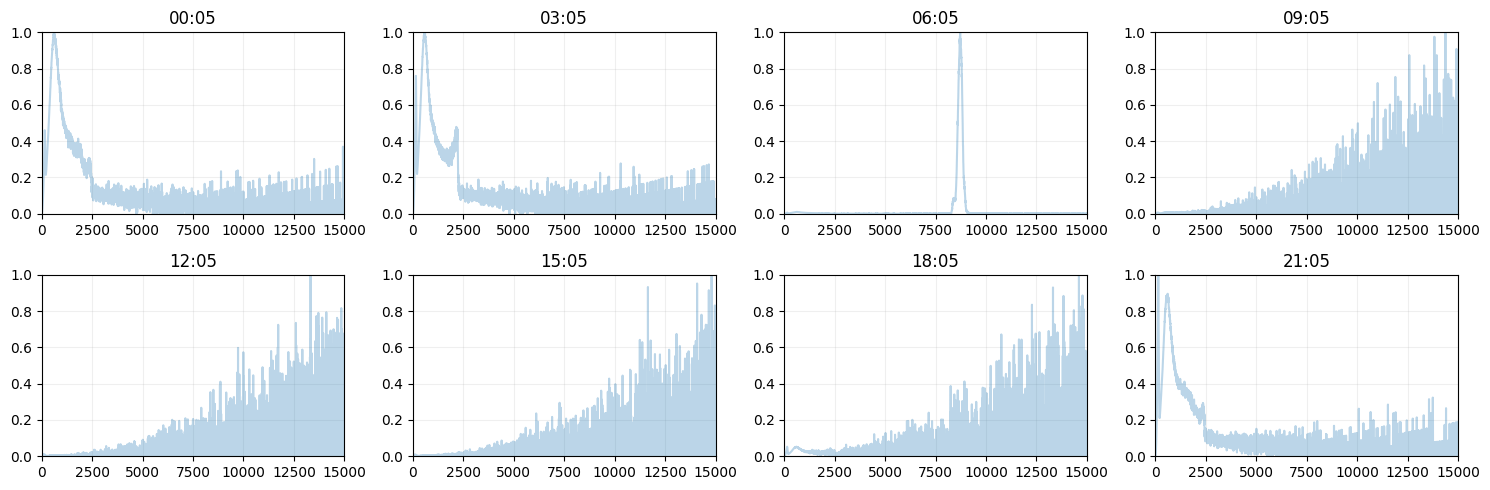

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(15,5))
axes = axes.flatten()

for ax, (t, df) in zip(axes, dfs.items()):

    # ---- Original ----
    ax.plot(
        df["range_m"],
        df["range2_norm"],
        label="Original",
        alpha=0.3
    )

    # # ---- Smoothed ----
    # ax.plot(
    #     df["range_m"],
    #     df["range2_smooth"],
    #     label="SavGol",
    #     linewidth=2
    # )

    ax.set_title(t)
    ax.set_xlim(0, 15000)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

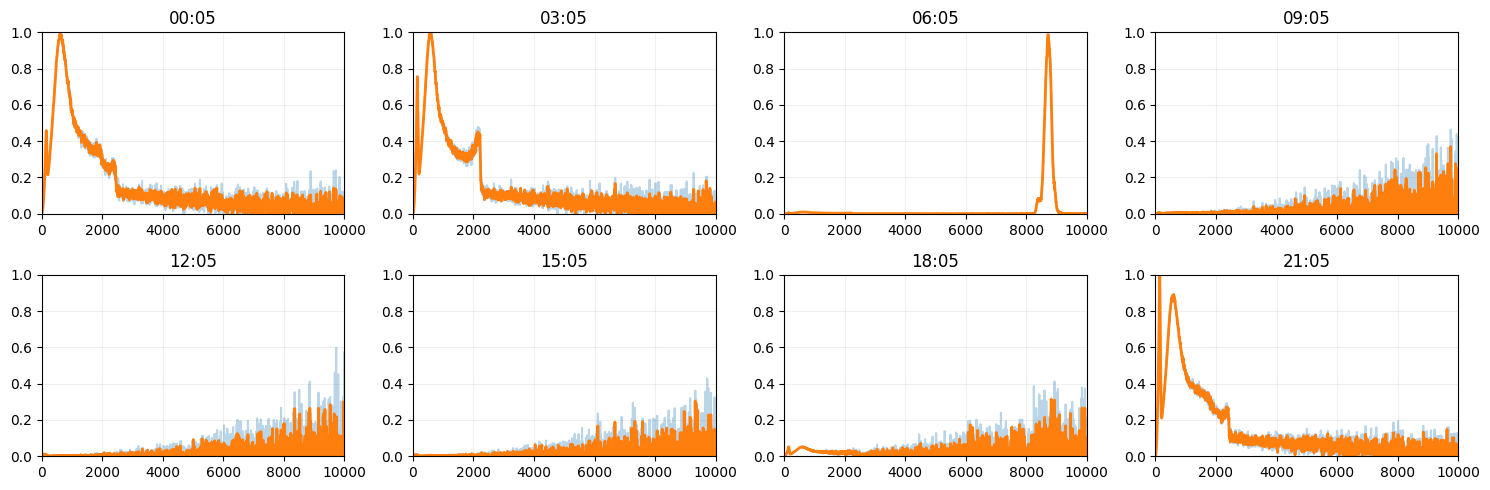

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(15,5))
axes = axes.flatten()

for ax, (t, df) in zip(axes, dfs.items()):

    # ---- Original ----
    ax.plot(
        df["range_m"],
        df["range2_norm"],
        label="Original",
        alpha=0.3
    )

    # ---- Smoothed ----
    ax.plot(
        df["range_m"],
        df["range2_smooth"],
        label="SavGol",
        linewidth=2
    )

    ax.set_title(t)
    ax.set_xlim(0, 10000)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

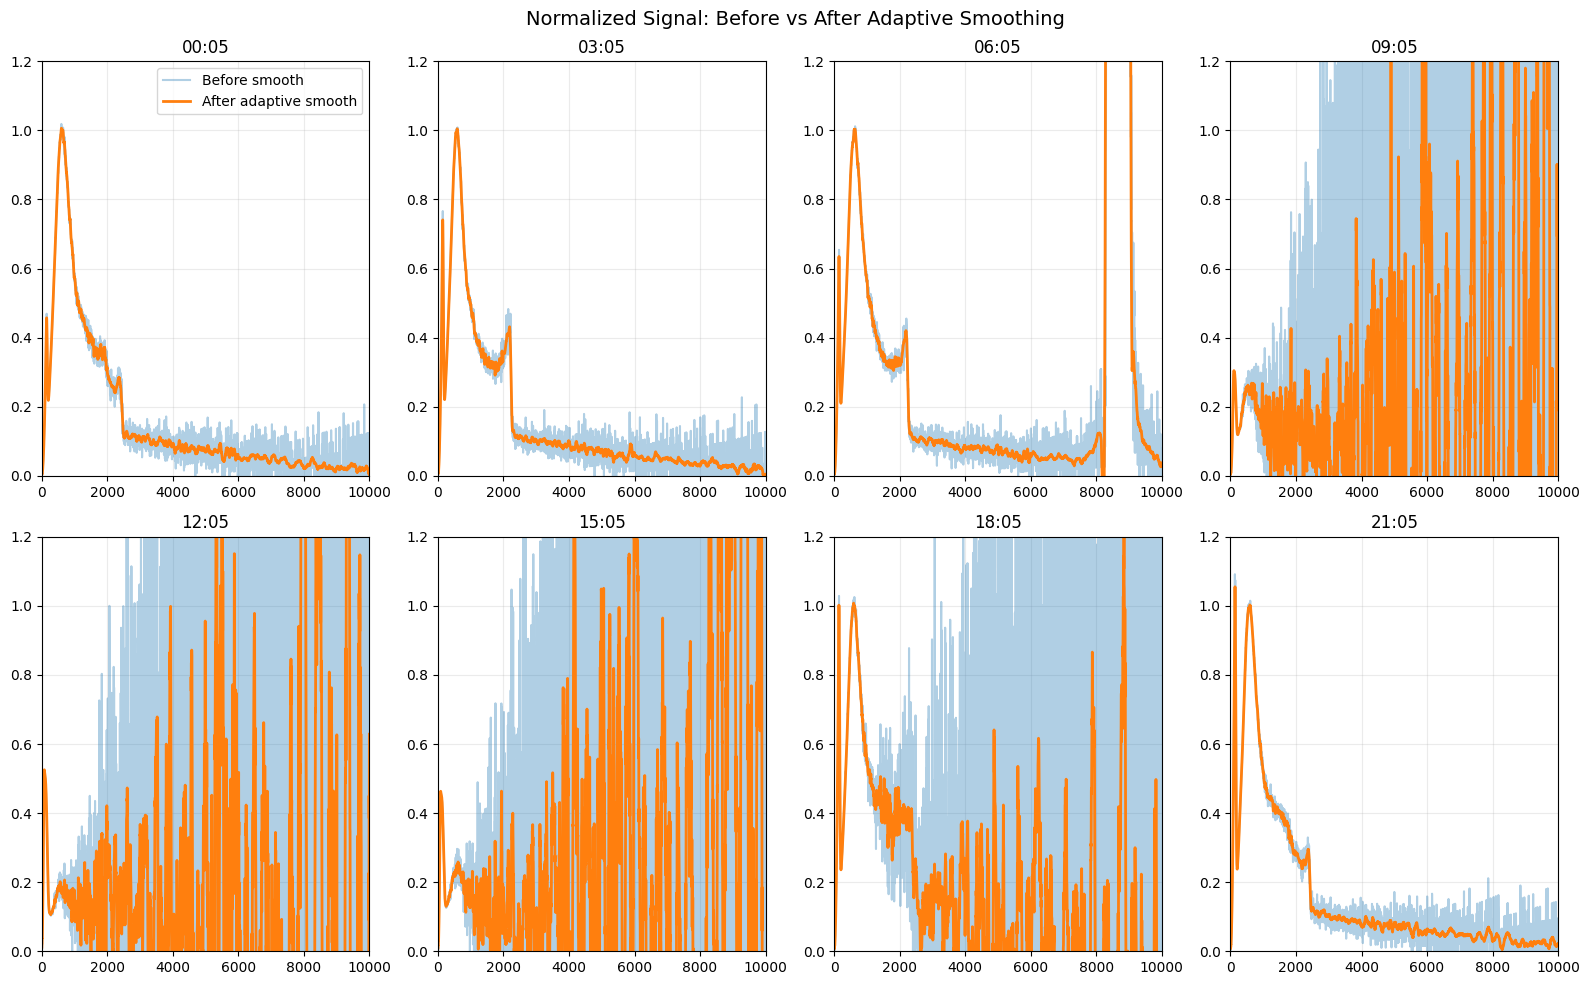

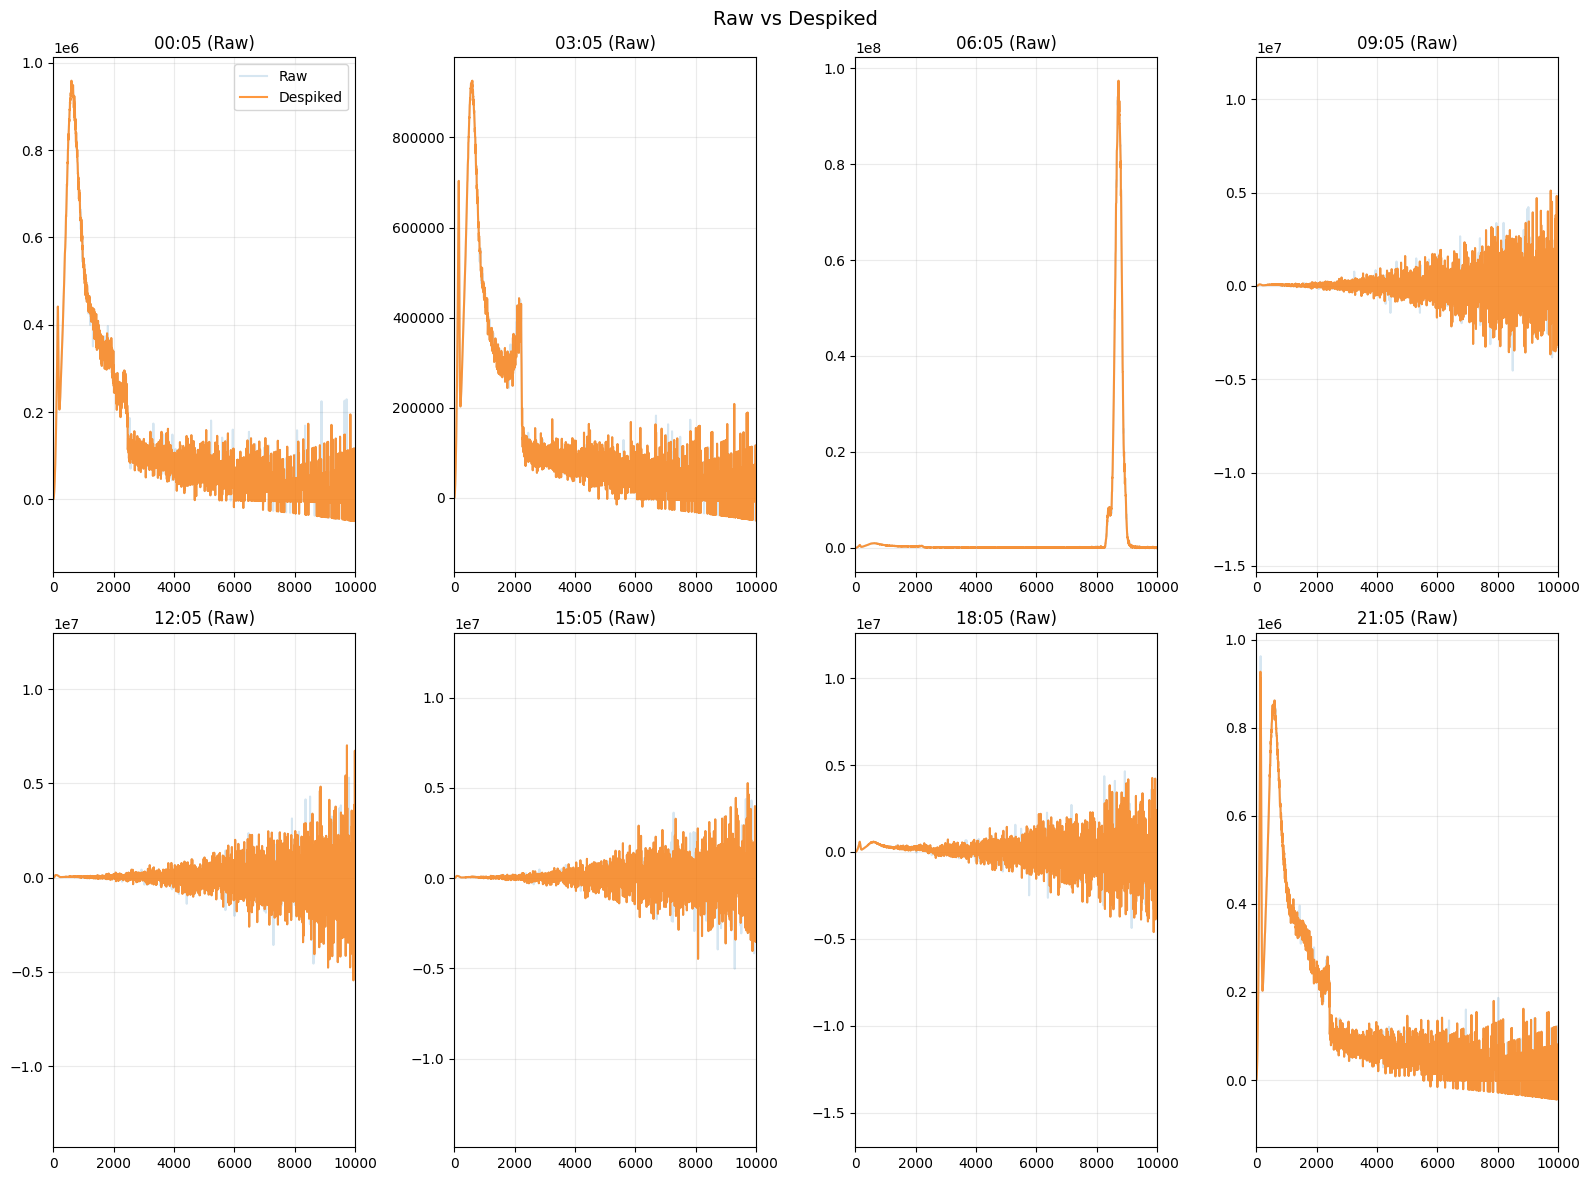

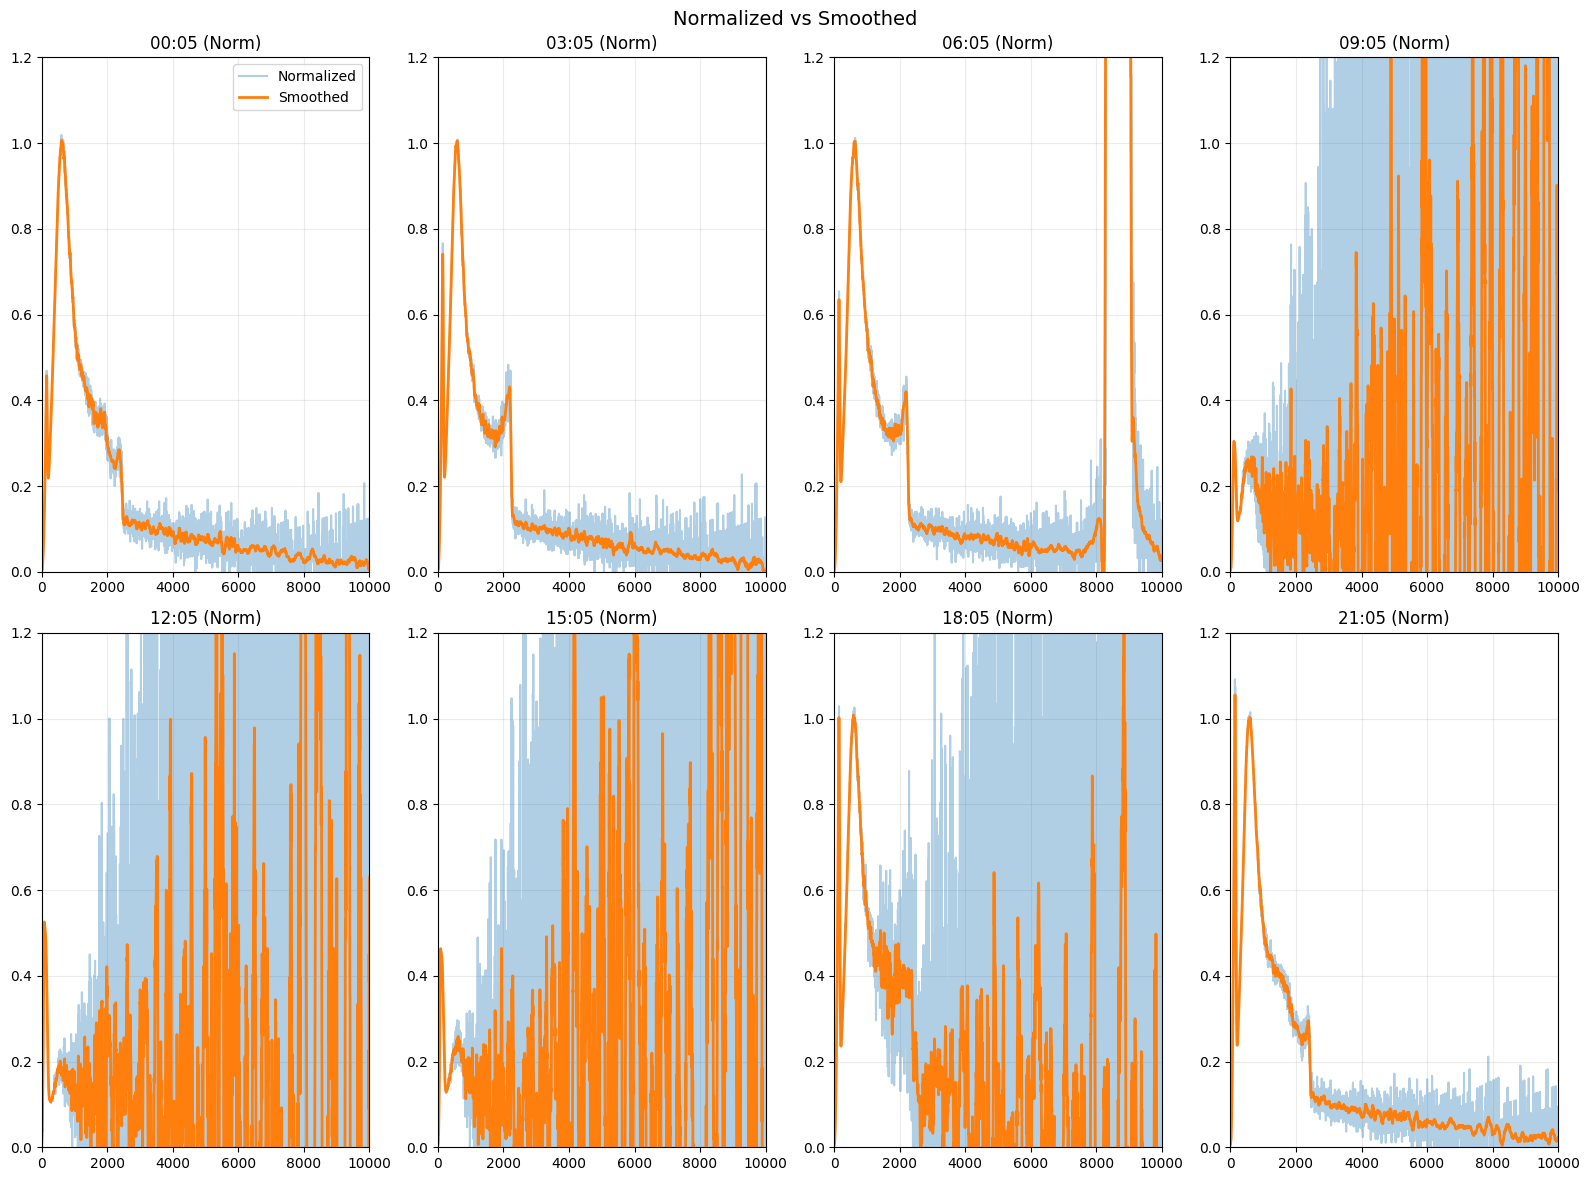

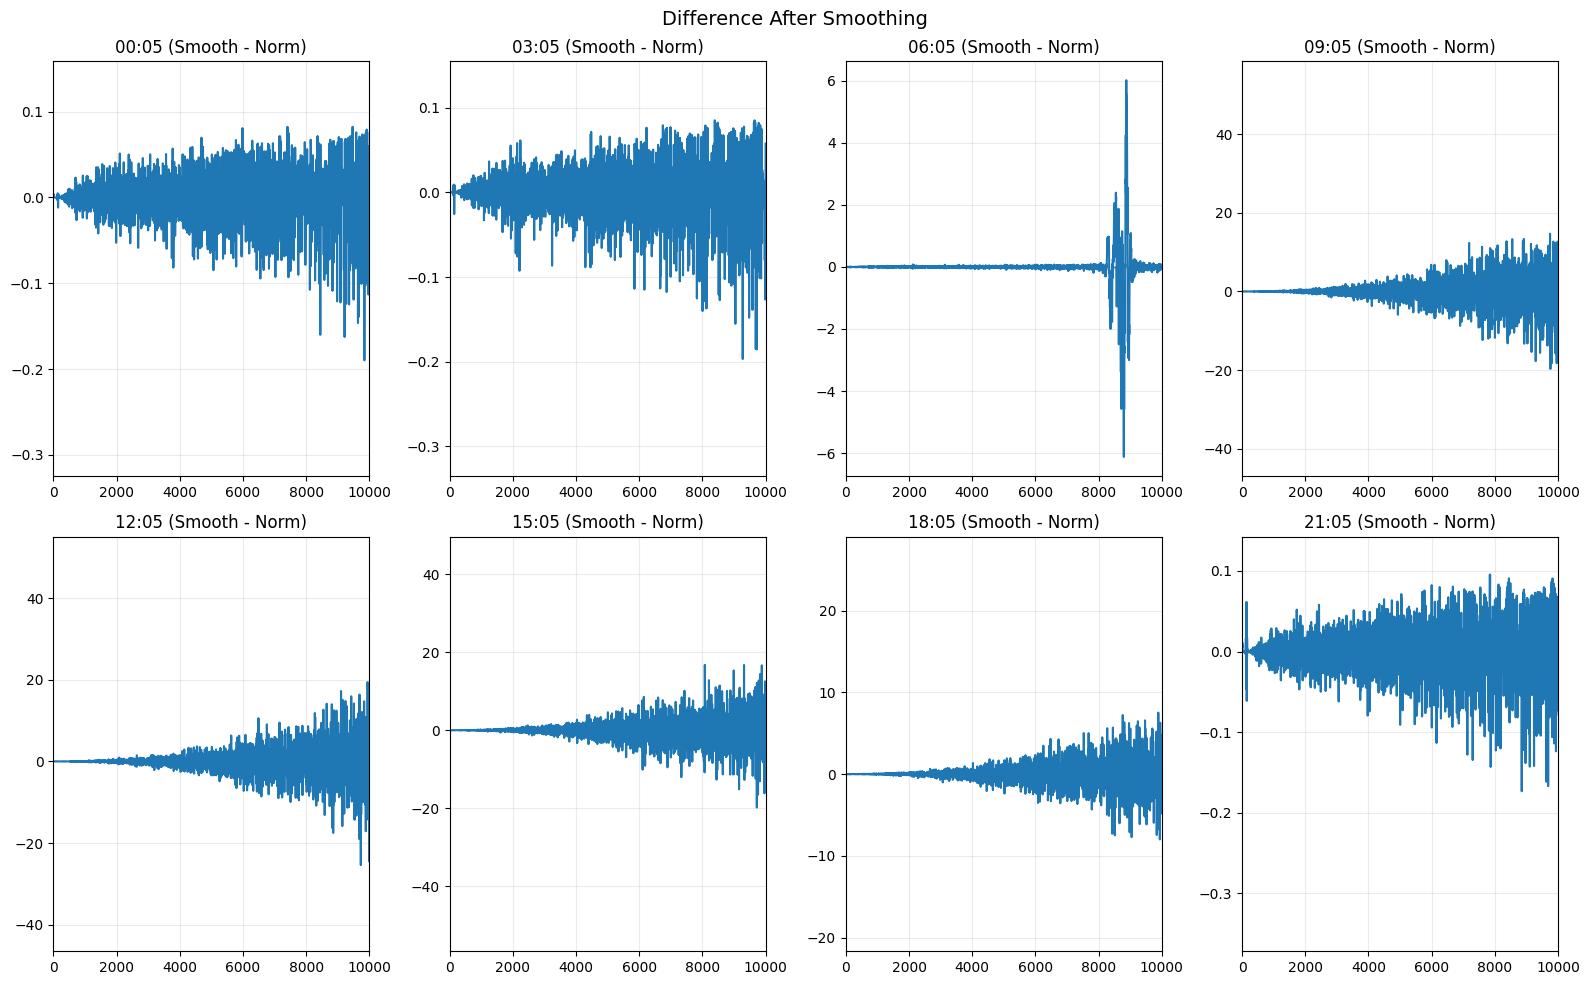

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# =========================================================
# 1) DESPIKE WITH ROLLING MEDIAN + MAD
# =========================================================
def despike_median(df, col="range2_corrected_counts", window=11, threshold=5):
    df = df.copy()
    y = df[col].astype(float).values

    s = pd.Series(y)

    # rolling median
    med = s.rolling(window=window, center=True, min_periods=1).median().values

    # residual
    resid = np.abs(y - med)

    # rolling MAD
    mad = pd.Series(resid).rolling(window=window, center=True, min_periods=1).median().values

    # avoid zero MAD
    valid_mad = mad[np.isfinite(mad) & (mad > 0)]
    if len(valid_mad) > 0:
        mad_fill = np.nanmedian(valid_mad)
    else:
        mad_fill = 1.0

    mad = np.where((~np.isfinite(mad)) | (mad == 0), mad_fill, mad)

    spike_mask = resid > (threshold * mad)

    y_clean = y.copy()
    y_clean[spike_mask] = med[spike_mask]

    df[col + "_despike"] = y_clean
    df["spike_mask"] = spike_mask
    return df


# =========================================================
# 2) ROBUST NORMALIZATION
#    Normalize using percentile in a selected range,
#    instead of global max
# =========================================================
def robust_normalize_in_range(
    df,
    col="range2_corrected_counts_despike",
    rmin=300,
    rmax=3000,
    q=99
):
    df = df.copy()

    mask = (df["range_m"] >= rmin) & (df["range_m"] <= rmax)
    vals = df.loc[mask, col].astype(float).values
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        df["range2_norm"] = np.nan
        return df

    scale = np.nanpercentile(vals, q)

    if np.isfinite(scale) and scale != 0:
        df["range2_norm"] = df[col] / scale
    else:
        df["range2_norm"] = np.nan

    return df


# =========================================================
# 3) ADAPTIVE SAVGOL SMOOTHING
#    small window near range, larger window far range
# =========================================================
def adaptive_savgol(df, col="range2_norm"):
    df = df.copy()
    x = df["range_m"].astype(float).values
    y = df[col].astype(float).values

    y_smooth = np.full_like(y, np.nan, dtype=float)

    for i in range(len(y)):
        r = x[i]

        # adaptive window size by range
        if r < 2000:
            w = 11
        elif r < 6000:
            w = 31
        else:
            w = 71

        if w % 2 == 0:
            w += 1

        i0 = max(0, i - w // 2)
        i1 = min(len(y), i + w // 2 + 1)

        segment = y[i0:i1]

        # keep only finite values
        finite_mask = np.isfinite(segment)
        seg = segment[finite_mask]

        if len(seg) < 5:
            continue

        w_local = min(w, len(seg))
        if w_local % 2 == 0:
            w_local -= 1

        if w_local < 5:
            continue

        polyorder = min(2, w_local - 1)

        try:
            seg_smooth = savgol_filter(seg, window_length=w_local, polyorder=polyorder)
            y_smooth[i] = seg_smooth[len(seg) // 2]
        except Exception:
            y_smooth[i] = np.nan

    df["range2_smooth"] = y_smooth
    return df


# =========================================================
# 4) COMPLETE PIPELINE FOR ONE DF
# =========================================================
def process_profile(
    df,
    raw_col="range2_corrected_counts",
    despike_window=11,
    despike_threshold=5,
    norm_rmin=300,
    norm_rmax=3000,
    norm_q=99
):
    df = df.copy()

    # despike raw signal
    df = despike_median(
        df,
        col=raw_col,
        window=despike_window,
        threshold=despike_threshold
    )

    # robust normalize despiked signal
    df = robust_normalize_in_range(
        df,
        col=raw_col + "_despike",
        rmin=norm_rmin,
        rmax=norm_rmax,
        q=norm_q
    )

    # adaptive smooth normalized signal
    df = adaptive_savgol(df, col="range2_norm")

    return df


# =========================================================
# 5) PROCESS ALL DFS
# =========================================================
def process_dfs(
    dfs,
    raw_col="range2_corrected_counts",
    despike_window=11,
    despike_threshold=5,
    norm_rmin=300,
    norm_rmax=3000,
    norm_q=99
):
    processed = {}

    for t, df in dfs.items():
        processed[t] = process_profile(
            df,
            raw_col=raw_col,
            despike_window=despike_window,
            despike_threshold=despike_threshold,
            norm_rmin=norm_rmin,
            norm_rmax=norm_rmax,
            norm_q=norm_q
        )

    return processed


# =========================================================
# 6) FIGURE 1: NORMALIZED BEFORE VS AFTER
# =========================================================
def plot_compare_all(
    dfs_processed,
    xlim=(0, 10000),
    ylim=(0, 1.2),
    ncols=4,
    figsize=(16, 10)
):
    n = len(dfs_processed)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for ax, (t, df) in zip(axes, dfs_processed.items()):
        ax.plot(
            df["range_m"],
            df["range2_norm"],
            label="Before smooth",
            alpha=0.35
        )

        ax.plot(
            df["range_m"],
            df["range2_smooth"],
            label="After adaptive smooth",
            linewidth=2
        )

        ax.set_title(t)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.25)

    # turn off unused axes
    for ax in axes[len(dfs_processed):]:
        ax.axis("off")

    axes[0].legend()
    fig.suptitle("Normalized Signal: Before vs After Adaptive Smoothing", fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================================================
# 7) FIGURE 2: RAW -> DESPIKED -> NORMALIZED+SMOOTHED
# =========================================================
def plot_pipeline_all(
    dfs_processed,
    raw_col="range2_corrected_counts",
    xlim=(0, 10000),
    ylim_raw=None,
    ylim_norm=(0, 1.2),
    ncols=4,
    figsize=(16, 12)
):
    n = len(dfs_processed)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (t, df) in zip(axes, dfs_processed.items()):
        # raw
        ax.plot(
            df["range_m"],
            df[raw_col],
            label="Raw",
            alpha=0.18
        )

        # despiked raw
        ax.plot(
            df["range_m"],
            df[raw_col + "_despike"],
            label="Despiked",
            alpha=0.8
        )

        ax.set_title(f"{t} (Raw)")
        ax.set_xlim(*xlim)
        if ylim_raw is not None:
            ax.set_ylim(*ylim_raw)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(dfs_processed):]:
        ax.axis("off")

    axes[0].legend()
    fig.suptitle("Raw vs Despiked", fontsize=14)
    plt.tight_layout()
    plt.show()

    # second figure for normalized + smoothed
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (t, df) in zip(axes, dfs_processed.items()):
        ax.plot(
            df["range_m"],
            df["range2_norm"],
            label="Normalized",
            alpha=0.35
        )

        ax.plot(
            df["range_m"],
            df["range2_smooth"],
            label="Smoothed",
            linewidth=2
        )

        ax.set_title(f"{t} (Norm)")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim_norm)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(dfs_processed):]:
        ax.axis("off")

    axes[0].legend()
    fig.suptitle("Normalized vs Smoothed", fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================================================
# 8) OPTIONAL: DIFFERENCE PLOT
# =========================================================
def plot_difference_all(
    dfs_processed,
    xlim=(0, 10000),
    ncols=4,
    figsize=(16, 10)
):
    n = len(dfs_processed)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (t, df) in zip(axes, dfs_processed.items()):
        diff = df["range2_smooth"] - df["range2_norm"]

        ax.plot(df["range_m"], diff)
        ax.axhline(0, linestyle="--", linewidth=1)

        ax.set_title(f"{t} (Smooth - Norm)")
        ax.set_xlim(*xlim)
        ax.grid(True, alpha=0.25)

    for ax in axes[len(dfs_processed):]:
        ax.axis("off")

    fig.suptitle("Difference After Smoothing", fontsize=14)
    plt.tight_layout()
    plt.show()


# =========================================================
# 9) YOUR INPUT DICTIONARY
# =========================================================
# Example:
# dfs = {
#     "04:05": df_405,
#     "04:35": df_435,
#     ...
#     "09:35": df_935,
# }


# =========================================================
# 10) RUN EVERYTHING
# =========================================================
dfs_processed = process_dfs(
    dfs,
    raw_col="range2_corrected_counts",   # change if needed
    despike_window=11,
    despike_threshold=5,
    norm_rmin=300,
    norm_rmax=3000,
    norm_q=99
)

# Figure 1: Before vs After smoothing
plot_compare_all(
    dfs_processed,
    xlim=(0, 10000),
    ylim=(0, 1.2),
    ncols=4,
    figsize=(16, 10)
)

# Figure 2: Raw vs Despiked, then Normalized vs Smoothed
plot_pipeline_all(
    dfs_processed,
    raw_col="range2_corrected_counts",
    xlim=(0, 10000),
    ylim_raw=None,       # can set e.g. (0, 5e10) if needed
    ylim_norm=(0, 1.2),
    ncols=4,
    figsize=(16, 12)
)

# Figure 3: Difference
plot_difference_all(
    dfs_processed,
    xlim=(0, 10000),
    ncols=4,
    figsize=(16, 10)
)

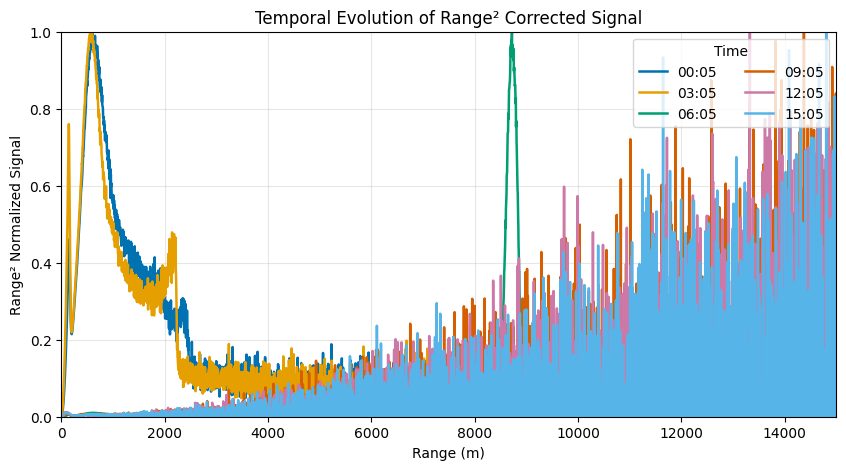

In [37]:
fig, ax = plt.subplots(figsize=(10,5))

# ---- Pack your data (timestamps) ----

# ---- Okabe–Ito colors ----
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]

# ---- Plot ----
for (label, df), c in zip(dfs.items(), colors):
    ax.plot(
        df["range_m"],
        df["range2_norm"],
        label=label,
        color=c,
        linewidth=1.8
    )

# ---- Labels ----
ax.set_xlabel("Range (m)")
ax.set_ylabel("Range² Normalized Signal")
ax.set_title("Temporal Evolution of Range² Corrected Signal")

ax.set_xlim(0, 15000)
ax.set_ylim(0, 1)

ax.grid(True, alpha=0.3)

ax.legend(title="Time", loc="upper right", ncol=2)

# ---- Save ----
plt.savefig("temporal_evolution.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os


items = list(dfs.items())
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]

frame_files = []

for i in range(len(items)):
    fig, ax = plt.subplots(figsize=(10, 5))

    for j in range(i + 1):
        label, df = items[j]
        ax.plot(
            df["range_m"],
            df["range2_norm"],
            label=label,
            color=colors[j],
            linewidth=2
        )

    ax.set_xlabel("Range (m)")
    ax.set_ylabel("Range² Normalized Signal")
    ax.set_title("Temporal Evolution of Range² Normalized Signal")
    ax.set_xlim(0, 15000)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Time", loc="upper right", ncol=2)

    fname = f"frame_{i:02d}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    frame_files.append(fname)
    plt.close(fig)

images = [imageio.imread(f) for f in frame_files]
imageio.mimsave("temporal_evolution_cumulative.gif", images, duration=10.0)

for f in frame_files:
    os.remove(f)

TypeError: 'set' object is not subscriptable

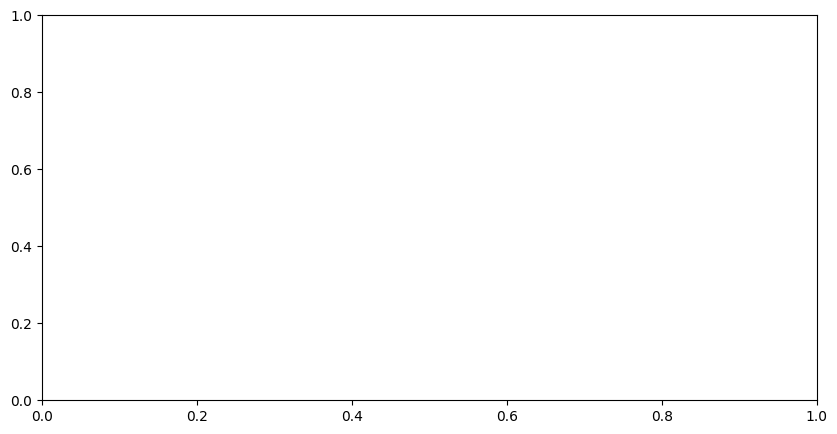

In [49]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

# dfs = {
#     "04:05": df_405,
#     "04:35": df_435,
#     "05:05": df_505,
#     "05:35": df_535,
#     "06:05": df_605,
#     "06:35": df_635,
# }

colors = {
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
}

xlims = {
    "00:05": (0, 3000),
    "03:05": (0, 3000),
    "06:05": (0, 5000),
    "09:05": (0, 5000),
    "12:05": (0, 8000),
    "15:05": (0, 15000),
    "18:05": (0, 15000),
    "21:05": (0, 15000),
}

frame_files = []

for i, (label, df) in enumerate(dfs.items()):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        df["range_m"],
        df["range2_norm"],
        color=colors[label],
        linewidth=2,
        label=label
    )

    ax.set_xlim(*xlims[label])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Range (m)")
    ax.set_ylabel("Range² Normalized Signal")
    ax.set_title(f"Signal at {label}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    fname = f"frame_{i:02d}.png"
    plt.savefig(fname, dpi=150)   # ✅ no bbox_inches="tight"
    frame_files.append(fname)
    plt.close(fig)

images = [imageio.imread(f) for f in frame_files]
imageio.mimsave("temporal_variable_zoom.gif", images, duration=20.0)

for f in frame_files:
    os.remove(f)

In [7]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
import numpy as np

# ---- Create output folder ----
output_dir = "frames_png"
os.makedirs(output_dir, exist_ok=True)

# ---- Data ----
# dfs = {
#     "04:05": df_405,
#     "04:35": df_435,
#     "05:05": df_505,
#     "05:35": df_535,
#     "06:05": df_605,
#     "06:35": df_635,
#     "07:05": df_705,
#     "07:35": df_735,
#     "08:05": df_805,
#     "08:35": df_835,
#     "09:05": df_905,
#     "09:35": df_935,
# }

# ---- Sort ----
dfs = dict(sorted(dfs.items()))

# ---- Colors ----
colors_list = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
    "#999999",  # gray
    "#332288",  # deep blue
    "#88CCEE",  # light cyan (NEW)
    "#44AA99",  # teal (NEW)
]
colors = {k: c for k, c in zip(dfs.keys(), colors_list)}

frame_files = []
near_xlim = (0, 3000)

for i, (label, df) in enumerate(dfs.items()):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Full range ----
    ax1.plot(df["range_m"], df["range2_norm"], color=colors[label], linewidth=2)
    ax1.set_title(f"{label} Full Range")
    ax1.set_xlim(0, 15000)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("Range (m)")
    ax1.set_ylabel("Range² Normalized Signal")
    ax1.grid(True, alpha=0.3)

    # ---- Near range ----
    ax2.plot(df["range_m"], df["range2_norm"], color=colors[label], linewidth=2)
    ax2.set_title(f"{label} Near Range")
    ax2.set_xlim(*near_xlim)

    mask = (df["range_m"] >= near_xlim[0]) & (df["range_m"] <= near_xlim[1])
    y_zoom = df.loc[mask, "range2_norm"].dropna()

    if len(y_zoom) > 0:
        ymin = np.percentile(y_zoom, 2)
        ymax = np.percentile(y_zoom, 98)

        if ymax <= ymin:
            ymin, ymax = y_zoom.min(), y_zoom.max()

        ypad = 0.01 if ymax == ymin else 0.08 * (ymax - ymin)
        ax2.set_ylim(ymin - ypad, ymax + ypad)
    else:
        ax2.set_ylim(0, 1)

    ax2.set_xlabel("Range (m)")
    ax2.set_ylabel("Range² Normalized Signal")
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"Signal Evolution at {label}")

    # ---- Save PNG ----
    fname = os.path.join(output_dir, f"{label.replace(':','')}.png")
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    frame_files.append(fname)

    plt.close(fig)

# ---- Optional: GIF ----
images = [imageio.imread(f) for f in frame_files]
imageio.mimsave("temporal_dualview.gif", images, duration=0.5)

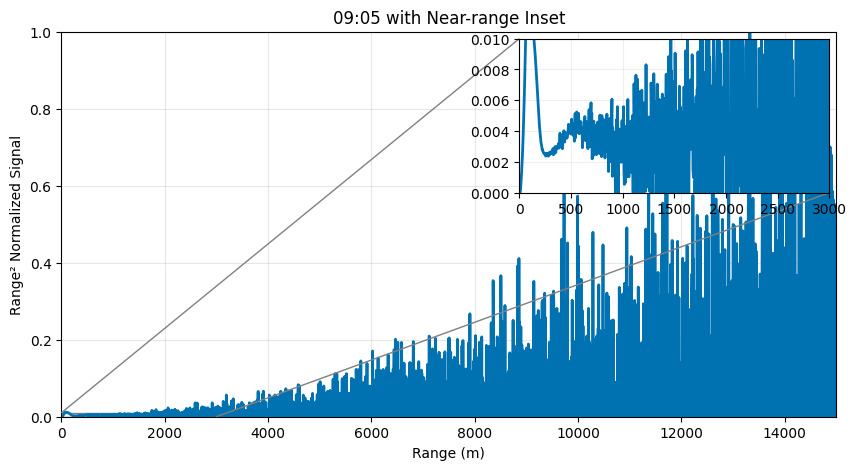

In [63]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_1205["range_m"], df_1205["range2_norm"], color="#0072B2", linewidth=2)
ax.set_xlim(0, 15000)
ax.set_ylim(0, 1)
ax.set_xlabel("Range (m)")
ax.set_ylabel("Range² Normalized Signal")
ax.set_title("09:05 with Near-range Inset")
ax.grid(True, alpha=0.3)

# inset เฉพาะบางกราฟ
axins = inset_axes(ax, width="40%", height="40%", loc="upper right")
axins.plot(df_1205["range_m"], df_1205["range2_norm"], color="#0072B2", linewidth=2)
axins.set_xlim(0, 3000)
axins.set_ylim(0, 0.01)
axins.grid(True, alpha=0.2)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

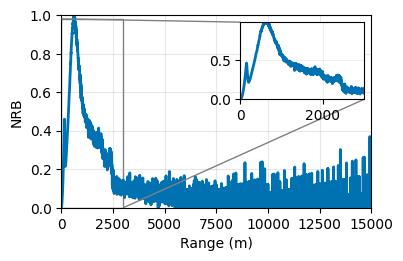

In [103]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

def plot_lidar_with_inset(df_timestamp):
    fig, ax = plt.subplots(figsize=(4, 2.5))

    x = df_timestamp["range_m"]
    y = df_timestamp["range2_norm"]

    # ---- Main plot ----
    ax.plot(x, y, color="#0072B2", linewidth=2)

    ax.set_xlim(0, 15000)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Range (m)")
    ax.set_ylabel("NRB")
    # ax.set_title("LiDAR Signal with Near-range Inset")
    ax.grid(True, alpha=0.3)

    # ---- Compute adaptive ylim for inset ----
    mask = (x >= 0) & (x <= 3000)
    y_near = y[mask]

    # avoid outliers (very important for LiDAR spikes)
    y_max = np.percentile(y_near, 99)   # robust max
    y_min = 0

    # fallback if signal too small
    if y_max < 0.02:
        y_max = 0.1

    # ---- Inset ----
    axins = inset_axes(ax, width="40%", height="40%", loc="upper right")

    axins.plot(x, y, color="#0072B2", linewidth=2)

    axins.set_xlim(0, 3000)
    axins.set_ylim(y_min, y_max)
    axins.grid(True, alpha=0.2)

    # ---- Connect box ----
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    plt.show()

plot_lidar_with_inset(df_0005)

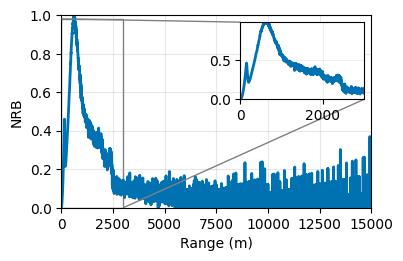

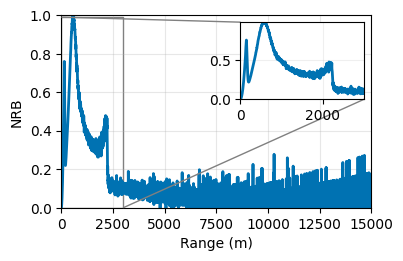

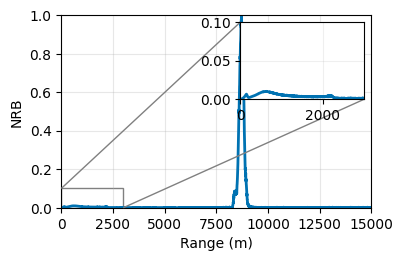

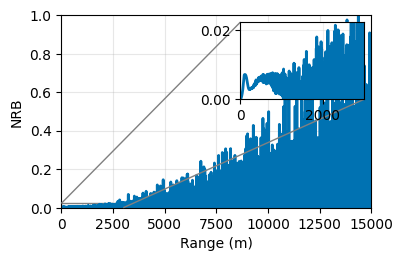

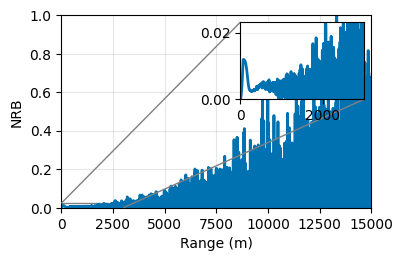

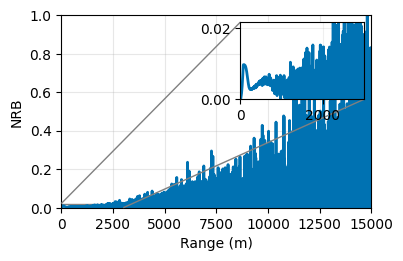

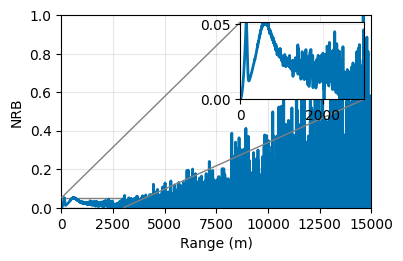

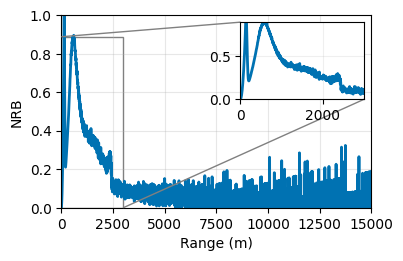

In [105]:
# dfs = {
#     "04:05": df_405,
#     "04:35": df_435,
#     "05:05": df_505,
#     "05:35": df_535,
#     "06:05": df_605,
#     "06:35": df_635,
#     "07:05": df_705,
#     "07:35": df_735,
#     "08:05": df_805,
#     "08:35": df_835,
#     "09:05": df_905,
#     "09:35": df_935,
# }
for time_str, df in dfs.items():
    plot_lidar_with_inset(df)

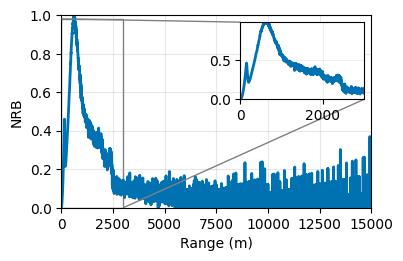

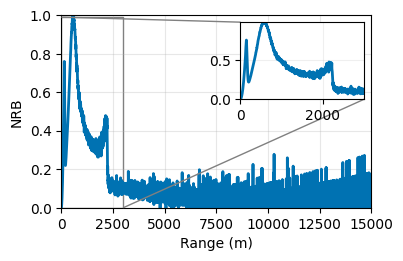

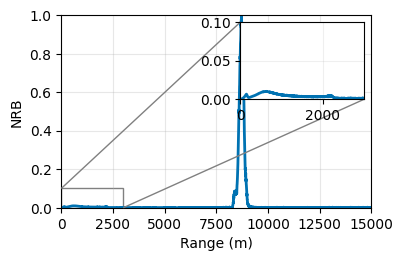

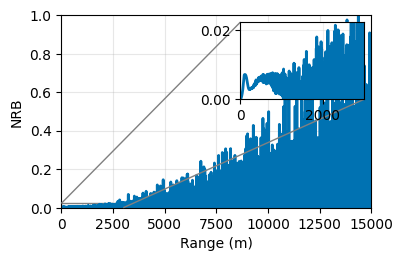

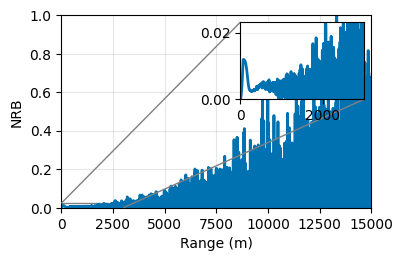

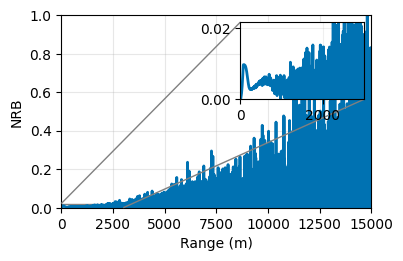

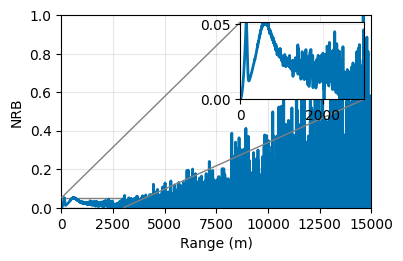

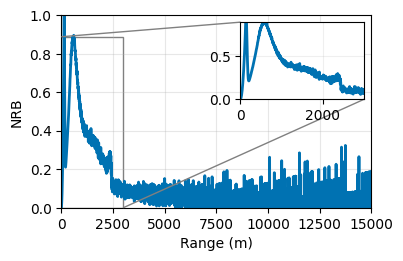

In [107]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import numpy as np

def plot_lidar_with_inset(df_timestamp, save_path=None):
    fig, ax = plt.subplots(figsize=(4, 2.5))

    x = df_timestamp["range_m"]
    y = df_timestamp["range2_norm"]

    # ---- Main plot ----
    ax.plot(x, y, color="#0072B2", linewidth=2)

    ax.set_xlim(0, 15000)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Range (m)")
    ax.set_ylabel("NRB")
    ax.grid(True, alpha=0.3)

    # ---- Compute adaptive ylim for inset ----
    mask = (x >= 0) & (x <= 3000)
    y_near = y[mask]

    y_max = np.percentile(y_near, 99)
    y_min = 0

    if y_max < 0.02:
        y_max = 0.1

    # ---- Inset ----
    axins = inset_axes(ax, width="40%", height="40%", loc="upper right")

    axins.plot(x, y, color="#0072B2", linewidth=2)

    axins.set_xlim(0, 3000)
    axins.set_ylim(y_min, y_max)
    axins.grid(True, alpha=0.2)

    # ---- Connect box ----
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    # ---- Save figure ----
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

for time_str, df in dfs.items():
    filename = f"lidar_{time_str}.png"
    plot_lidar_with_inset(df, save_path=filename)

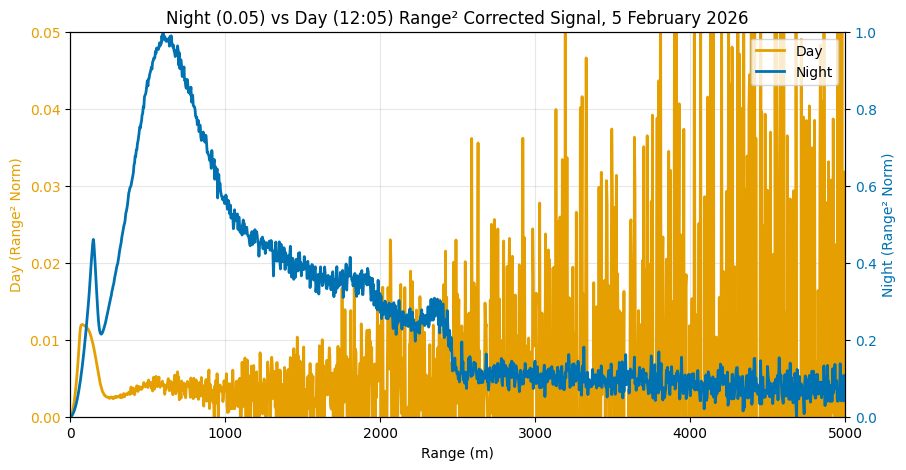

In [55]:
OKABE_ITO = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000"
}

fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Colors (Okabe–Ito) ----
c_day = "#E69F00"     # blue
c_night = "#0072B2"   # orange

# ---- Left axis (Day) ----
ax1.plot(
    df_1205["range_m"],
    df_1205["range2_norm"],
    label="Day",
    color=c_day,
    linewidth=2
)
ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Day (Range² Norm)", color=c_day)
ax1.tick_params(axis="y", labelcolor=c_day)

# ---- Right axis (Night) ----
ax2 = ax1.twinx()

ax2.plot(
    df_0005["range_m"],
    df_0005["range2_norm"],
    label="Night",
    color=c_night,
    linewidth=2,
    linestyle="-"   # 👈 helps distinguish further
)
ax2.set_ylabel("Night (Range² Norm)", color=c_night)
ax2.tick_params(axis="y", labelcolor=c_night)

# ---- Limits ----
ax1.set_xlim(0, 5000)
ax1.set_ylim(0, 0.05)
ax2.set_ylim(0, 1)

# ---- Title / grid ----
ax1.set_title("Night (0.05) vs Day (12:05) Range² Corrected Signal, 5 February 2026")
ax1.grid(True, alpha=0.3)

# ---- Combined legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True   # 👈 cleaner look
)

# ---- Save ----
plt.savefig("day_vs_night_dual_axis_zoom.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# # ---- DAY ----
# ax1.plot(
#     df_day["range_m"],
#     df_day["range2_norm"],
#     color="#E69F00",
#     linewidth=2,
#     label="Day"
# )
# ax1.set_ylim(0, 0.05)
# ax1.set_ylabel("Day Signal")
# ax1.set_title("Day vs Night (Separate Plots)")
# ax1.grid(True, alpha=0.3)
# ax1.legend()

# # ---- NIGHT ----
# ax2.plot(
#     df_night["range_m"],
#     df_night["range2_norm"],
#     color="#0072B2",
#     linewidth=2,
#     label="Night"
# )
# ax2.set_ylim(0, 1)
# ax2.set_xlabel("Range (m)")
# ax2.set_ylabel("Night Signal")
# ax2.grid(True, alpha=0.3)
# ax2.legend()

# plt.tight_layout()
# plt.savefig("day_night_subplots.png", dpi=300, bbox_inches="tight")
# plt.show()

In [70]:
# fig, ax = plt.subplots(figsize=(10,5))

# x = df_day["range_m"]
# y1 = df_day["range2_norm"]
# y2 = df_night["range2_norm"]

# # ax.plot(x, y1, label="Day")
# # ax.plot(x, y2, label="Night")

# # 👉 Fill the difference
# ax.fill_between(
#     x,
#     y1,
#     y2,
#     color="red",
#     alpha=1,
#     label="Difference"
# )

# ax.set_xlabel("Range (m)")
# ax.set_ylabel("Range² Normalized Signal")
# ax.set_title("Day vs Night Range² Corrected Signal")

# ax.set_xlim(0, 15000)
# ax.set_ylim(0, 1)

# ax.grid(True, alpha=0.3)
# ax.legend(loc="upper right")

# plt.show()

In [75]:
# fig, ax = plt.subplots(figsize=(10,5))

# ax.plot(df_day["range_m"], df_day["photon_counting"]/df_day["pc_sterr"], label="Day PC")
# ax.plot(df_night["range_m"], df_night["photon_counting"]/df_night["pc_sterr"], label="Night PC")
# ax.plot(df_day["range_m"], df_day["analog"]/df_day["analog_sterr"], label="Day AC")
# ax.plot(df_night["range_m"], df_night["analog"]/df_night["analog_sterr"], label="Night AC")

# ax.set_xlabel("Range (m)")
# ax.set_ylabel("Signal to Noise Ratio")
# ax.set_title("Day vs Night SNR")
# plt.yscale("linear")
# ax.set_xlim(0, 15000)
# ax.set_ylim(0, 4)
# ax.grid(True, alpha=0.3)

# # 👉 ตรงนี้
# ax.legend(loc="upper right")

# plt.show()

In [77]:
# fig, ax = plt.subplots(figsize=(10,5))

# # ax.plot(df_day["range_m"], df_day["pc_sterr"], label="Day PC")
# # ax.plot(df_night["range_m"], df_night["pc_sterr"], label="Night PC")
# # ax.plot(df_day["range_m"], df_day["analog_sterr"], label="Day AC")
# ax.plot(df_night["range_m"], df_night["analog_sterr"], label="Night AC")

# ax.set_xlabel("Range (m)")
# ax.set_ylabel("Signal to Noise Ratio")
# ax.set_title("Day vs Night SNR")
# plt.yscale("linear")
# ax.set_xlim(8000, 15000)

# ax.grid(True, alpha=0.3)

# # 👉 ตรงนี้
# ax.legend(loc="upper right")

# plt.show()

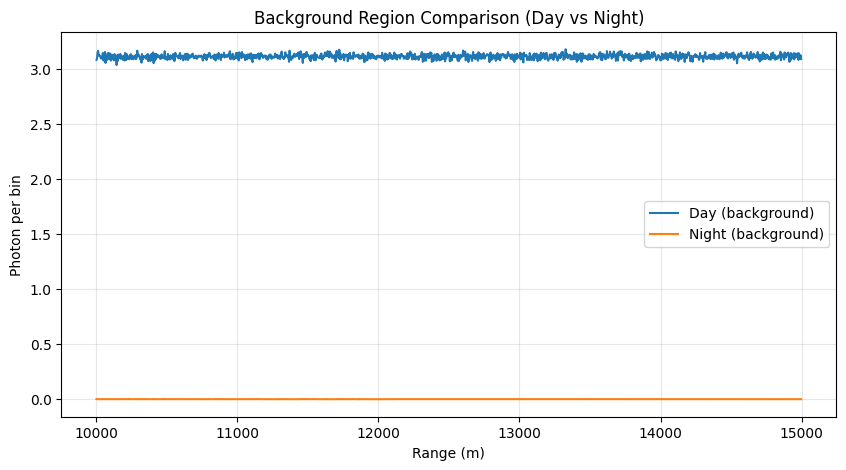

In [81]:
# mask background region
bg_mask_day = (
    (df_1205["range_m"] >= config["bg_start_m"]) &
    (df_1205["range_m"] <= config["bg_end_m"])
)

bg_mask_night = (
    (df_0005["range_m"] >= config["bg_start_m"]) &
    (df_0005["range_m"] <= config["bg_end_m"])
)

# plot
plt.figure(figsize=(10,5))

plt.plot(
    df_1205.loc[bg_mask_day, "range_m"],
    df_1205.loc[bg_mask_day, "photon_per_bin"],
    label="Day (background)",
)

plt.plot(
    df_0005.loc[bg_mask_night, "range_m"],
    df_0005.loc[bg_mask_night, "photon_per_bin"],
    label="Night (background)",
)

plt.xlabel("Range (m)")
plt.ylabel("Photon per bin")
plt.title("Background Region Comparison (Day vs Night)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()



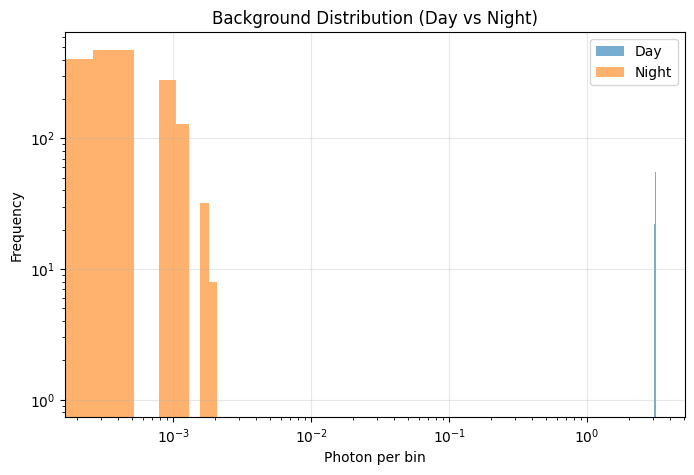

In [83]:
plt.figure(figsize=(8,5))

plt.hist(
    df_1205.loc[bg_mask_day, "photon_per_bin"],
    bins=50,
    alpha=0.6,
    label="Day"
)

plt.hist(
    df_0005.loc[bg_mask_night, "photon_per_bin"],
    bins=8,
    alpha=0.6,
    label="Night"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Photon per bin")
plt.ylabel("Frequency")
plt.title("Background Distribution (Day vs Night)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

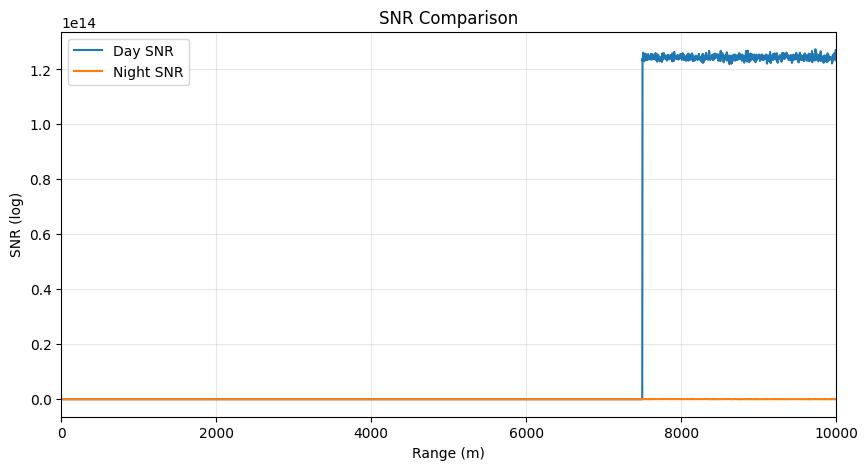

In [87]:
plt.figure(figsize=(10,5))

plt.plot(df_1205["range_m"], df_1205["SNR_Photon"], label="Day SNR")
plt.plot(df_0005["range_m"], df_0005["SNR_Photon"], label="Night SNR")

plt.yscale("linear")
plt.xlim(0, 10000)

plt.xlabel("Range (m)")
plt.ylabel("SNR (log)")
plt.title("SNR Comparison")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

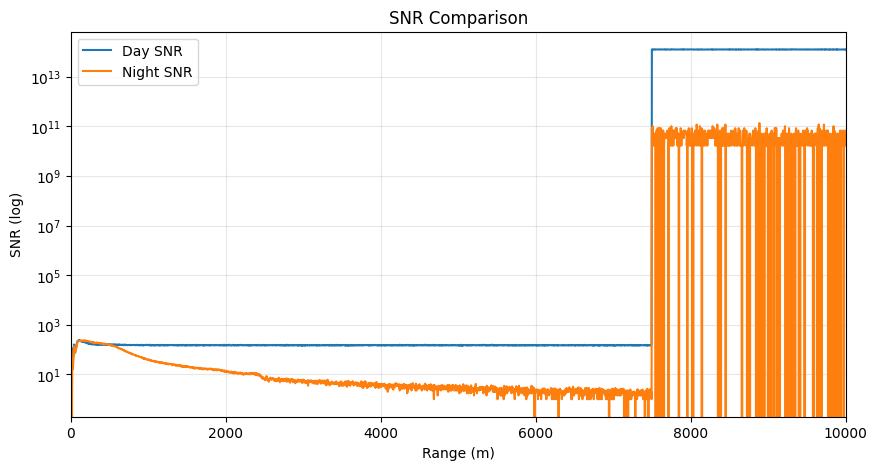

In [89]:
plt.figure(figsize=(10,5))

plt.plot(df_1205["range_m"], df_1205["SNR_Photon"], label="Day SNR")
plt.plot(df_0005["range_m"], df_0005["SNR_Photon"], label="Night SNR")

plt.yscale("log")
plt.xlim(0, 10000)

plt.xlabel("Range (m)")
plt.ylabel("SNR (log)")
plt.title("SNR Comparison")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

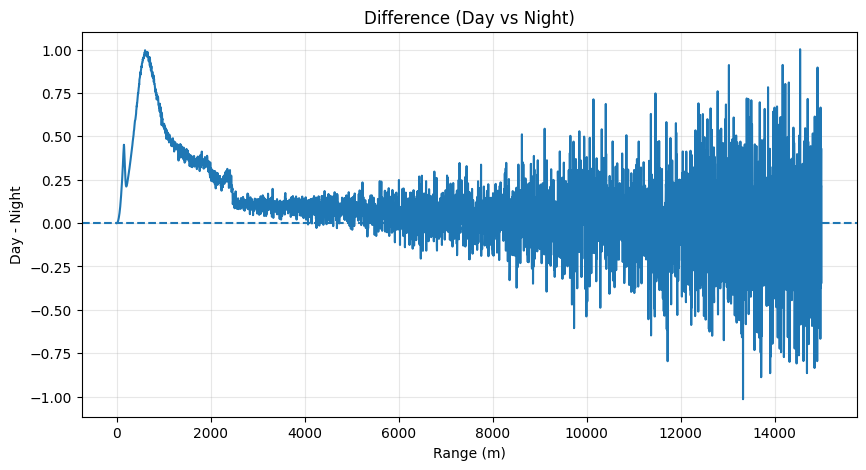

In [93]:
diff = df_0005["range2_norm"] - df_1205["range2_norm"]

plt.figure(figsize=(10,5))
plt.plot(df_1205["range_m"], diff)

plt.axhline(0, linestyle="--")

plt.xlabel("Range (m)")
plt.ylabel("Day - Night")
plt.title("Difference (Day vs Night)")

plt.grid(True, alpha=0.3)

plt.show()

In [97]:
df_0005["SNR_Photon"]

0       1.960787e+02
1       2.234301e+02
2       7.899544e+01
3       7.652444e+00
4       0.000000e+00
            ...     
3995    5.016720e+10
3996    0.000000e+00
3997    1.672240e+10
3998    0.000000e+00
3999    1.672240e+10
Name: SNR_Photon, Length: 4000, dtype: float64